# NB08 — Neural Collaborative Filtering (NCF)

Neural Collaborative Filtering (He et al., 2017) replaces the simple dot product of matrix factorisation with a deep neural network. The key idea: **user and item embeddings are learned jointly with a non-linear interaction function** rather than a linear dot product.

## Architecture — NeuMF

NeuMF combines two paths:

```
User ID ──► Embedding (GMF) ──┐
                               ├──► Element-wise product ──► GMF output
Item ID ──► Embedding (GMF) ──┘                                │
                                                               Concat ──► Dense ──► rating
User ID ──► Embedding (MLP) ──┐                                │
                               ├──► Concat ──► Dense × 3 ──► MLP output
Item ID ──► Embedding (MLP) ──┘
```

- **GMF** (Generalised Matrix Factorisation): non-linear element-wise user×item product
- **MLP** (Multi-Layer Perceptron): learns complex non-linear interactions from concatenated embeddings
- **NeuMF**: fuses both outputs, recovering the strengths of both architectures

**Implementation**: Uses PyTorch. Install instructions in the first cell.

## 1. Install & Import

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    """Install packages into the current kernel's Python."""
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import torch
    if '+cu' not in torch.__version__:
        raise ImportError("CPU build detected — reinstalling CUDA build.")
    print(f"PyTorch {torch.__version__} (CUDA) already installed.")
except ImportError as e:
    print(f"{e}\nInstalling PyTorch CUDA 12.6 build…")
    pip_install('torch', 'torchvision',
                '--index-url', 'https://download.pytorch.org/whl/cu126')
    import torch
    print(f"Installed PyTorch {torch.__version__}")


PyTorch 2.10.0+cu126 (CUDA) already installed.


In [2]:
import pathlib, time, pickle, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT      = pathlib.Path('../../').resolve()
MODELS    = ROOT / 'models'
PROCESSED = ROOT / 'data_science' / 'processed'
MOVIELENS = ROOT / 'data' / 'movielens'

print(f"Device   : {DEVICE}")
print(f"Root     : {ROOT}")
print(f"Models   : {MODELS}")

Device   : cuda
Root     : E:\Projects\Movies Recommendation Engine
Models   : E:\Projects\Movies Recommendation Engine\models


## 2. Load & Encode Data

In [3]:

# Load ratings splits
train_df = pd.read_parquet(PROCESSED / 'ratings_train.parquet',
                           columns=['userId', 'movieId', 'rating'])
val_df   = pd.read_parquet(PROCESSED / 'ratings_val.parquet',
                           columns=['userId', 'movieId', 'rating'])

# GPU unlocks full-data training:
# All 20.7M train ratings — RTX 4070 handles ~5K batches/epoch in ~2.5 min
# Val capped at 500K for fast per-epoch evaluation
VAL_SAMPLE = 500_000
np.random.seed(42)
val_idx  = np.random.choice(len(val_df), size=min(VAL_SAMPLE, len(val_df)), replace=False)
val_df   = val_df.iloc[val_idx].reset_index(drop=True)

# Encode userId and movieId as contiguous integers [0, N)
all_users  = pd.concat([train_df['userId'],  val_df['userId']]).unique()
all_movies = pd.concat([train_df['movieId'], val_df['movieId']]).unique()

user_enc  = {uid: i for i, uid in enumerate(all_users)}
movie_enc = {mid: i for i, mid in enumerate(all_movies)}

train_df['user_idx']  = train_df['userId'].map(user_enc)
train_df['movie_idx'] = train_df['movieId'].map(movie_enc)
val_df['user_idx']    = val_df['userId'].map(user_enc).fillna(-1).astype(int)
val_df['movie_idx']   = val_df['movieId'].map(movie_enc).fillna(-1).astype(int)

# Drop val rows with unseen users/items
val_df    = val_df[(val_df['user_idx'] >= 0) & (val_df['movie_idx'] >= 0)]

N_USERS     = len(user_enc)
N_MOVIES    = len(movie_enc)
GLOBAL_MEAN = float(train_df['rating'].mean())

print(f"Train rows : {len(train_df):,}  (full dataset — GPU enabled)")
print(f"Val rows   : {len(val_df):,}")
print(f"Users      : {N_USERS:,}")
print(f"Movies     : {N_MOVIES:,}")
print(f"Global mean: {GLOBAL_MEAN:.4f}")


Train rows : 20,720,316  (full dataset — GPU enabled)
Val rows   : 500,000
Users      : 244,905
Movies     : 28,733
Global mean: 3.5212


In [4]:
class RatingsDataset(Dataset):
    """PyTorch Dataset wrapping (user_idx, movie_idx, rating) triples."""
    def __init__(self, df: pd.DataFrame):
        self.users  = torch.tensor(df['user_idx'].values,  dtype=torch.long)
        self.movies = torch.tensor(df['movie_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

BATCH_SIZE = 4096
train_ds = RatingsDataset(train_df)
val_ds   = RatingsDataset(val_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Train batches: 5,059  |  Val batches: 123


## 3. Build the NeuMF Model

The NeuMF architecture has two independent embedding spaces:
- **GMF embeddings**: small (32-dim) → element-wise product → captures linear correlations
- **MLP embeddings**: larger (64-dim) → concatenated → passed through Dense layers → captures non-linear patterns

The final output is the sigmoid-scaled sum of GMF output and MLP output, clipped to [0.5, 5.0] rating range.

In [5]:
class NeuMF(nn.Module):
    """
    Neural Matrix Factorisation (He et al., 2017).
    Combines Generalised MF (element-wise product) with an MLP.
    Predicts explicit ratings (regression).
    """
    def __init__(self, n_users: int, n_items: int,
                 gmf_dim: int = 32, mlp_dim: int = 64,
                 mlp_layers: list[int] = [128, 64, 32],
                 dropout: float = 0.2):
        super().__init__()

        # GMF embeddings
        self.gmf_user_emb = nn.Embedding(n_users, gmf_dim)
        self.gmf_item_emb = nn.Embedding(n_items, gmf_dim)

        # MLP embeddings
        self.mlp_user_emb = nn.Embedding(n_users, mlp_dim)
        self.mlp_item_emb = nn.Embedding(n_items, mlp_dim)

        # MLP tower: input size = 2 * mlp_dim (user + item concat)
        mlp_in = mlp_dim * 2
        layers = []
        for out_size in mlp_layers:
            layers += [nn.Linear(mlp_in, out_size), nn.ReLU(), nn.Dropout(dropout)]
            mlp_in = out_size
        self.mlp_tower = nn.Sequential(*layers)

        # Final fusion layer: GMF output (gmf_dim) + MLP output (last layer size)
        self.output = nn.Linear(gmf_dim + mlp_layers[-1], 1)

        # Initialise weights
        nn.init.normal_(self.gmf_user_emb.weight, std=0.01)
        nn.init.normal_(self.gmf_item_emb.weight, std=0.01)
        nn.init.normal_(self.mlp_user_emb.weight, std=0.01)
        nn.init.normal_(self.mlp_item_emb.weight, std=0.01)

    def forward(self, user_ids: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        # GMF path: element-wise product
        gmf_u = self.gmf_user_emb(user_ids)   # (B, gmf_dim)
        gmf_i = self.gmf_item_emb(item_ids)   # (B, gmf_dim)
        gmf_out = gmf_u * gmf_i               # (B, gmf_dim)

        # MLP path: concat → dense layers
        mlp_u = self.mlp_user_emb(user_ids)   # (B, mlp_dim)
        mlp_i = self.mlp_item_emb(item_ids)   # (B, mlp_dim)
        mlp_in = torch.cat([mlp_u, mlp_i], dim=1)   # (B, mlp_dim*2)
        mlp_out = self.mlp_tower(mlp_in)       # (B, mlp_layers[-1])

        # Fuse + output
        fused = torch.cat([gmf_out, mlp_out], dim=1)
        # Scale sigmoid output from (0,1) to (0.5, 5.0)
        pred = 0.5 + 4.5 * torch.sigmoid(self.output(fused)).squeeze(1)
        return pred

# Instantiate and print summary
model = NeuMF(N_USERS, N_MOVIES, gmf_dim=32, mlp_dim=64,
              mlp_layers=[128, 64, 32], dropout=0.2).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"NeuMF model  |  Parameters: {total_params:,}")
print(model)

NeuMF model  |  Parameters: 26,296,161
NeuMF(
  (gmf_user_emb): Embedding(244905, 32)
  (gmf_item_emb): Embedding(28733, 32)
  (mlp_user_emb): Embedding(244905, 64)
  (mlp_item_emb): Embedding(28733, 64)
  (mlp_tower): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=64, out_features=1, bias=True)
)


## 4. Train NeuMF

In [6]:
def evaluate_loader(model, loader, device):
    """Compute RMSE and MAE over a DataLoader."""
    model.eval()
    se, ae, n = 0.0, 0.0, 0
    with torch.no_grad():
        for users, items, ratings in loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            preds = model(users, items)
            se += ((preds - ratings) ** 2).sum().item()
            ae += (preds - ratings).abs().sum().item()
            n  += len(ratings)
    return (se/n)**0.5, ae/n

# Hyperparameters:
# lr=5e-4 (slightly reduced from 1e-3 — with full data the gradient signal is much stronger)
# weight_decay=1e-4 (10x more L2 regularisation vs earlier run — embeds are 21M params)
# patience=3 — ReduceLROnPlateau allows 3 non-improving epochs before halving LR
N_EPOCHS     = 10
LR           = 5e-4
optimizer    = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion    = nn.MSELoss()
scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history       = {'train_rmse': [], 'val_rmse': [], 'train_mae': [], 'val_mae': []}
best_val_rmse = float('inf')
best_state    = None
prev_lr       = LR

print(f"Training NeuMF — {len(train_df):,} ratings, {N_EPOCHS} epochs on {DEVICE}…\n")
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_se, epoch_ae, epoch_n = 0.0, 0.0, 0
    t0 = time.time()
    for users, items, ratings in train_loader:
        users, items, ratings = users.to(DEVICE), items.to(DEVICE), ratings.to(DEVICE)
        optimizer.zero_grad()
        preds = model(users, items)
        loss  = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            epoch_se += ((preds - ratings)**2).sum().item()
            epoch_ae += (preds - ratings).abs().sum().item()
            epoch_n  += len(ratings)

    train_rmse = (epoch_se / epoch_n) ** 0.5
    train_mae  = epoch_ae / epoch_n
    val_rmse, val_mae = evaluate_loader(model, val_loader, DEVICE)
    scheduler.step(val_rmse)

    history['train_rmse'].append(train_rmse)
    history['val_rmse'].append(val_rmse)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    cur_lr = optimizer.param_groups[0]['lr']
    lr_tag = f"  ↓ LR→{cur_lr:.1e}" if cur_lr != prev_lr else ""
    prev_lr = cur_lr

    print(f"Epoch {epoch:>2}/{N_EPOCHS}  "
          f"train RMSE={train_rmse:.4f} MAE={train_mae:.4f}  "
          f"val RMSE={val_rmse:.4f} MAE={val_mae:.4f}  "
          f"({time.time()-t0:.0f}s){lr_tag}")

# Restore best checkpoint
model.load_state_dict(best_state)
print(f"\nBest val RMSE: {best_val_rmse:.4f}")


Training NeuMF — 20,720,316 ratings, 10 epochs on cuda…

Epoch  1/10  train RMSE=0.8887 MAE=0.6857  val RMSE=1.0043 MAE=0.7564  (411s)
Epoch  2/10  train RMSE=0.8509 MAE=0.6539  val RMSE=1.0005 MAE=0.7560  (400s)
Epoch  3/10  train RMSE=0.8368 MAE=0.6424  val RMSE=0.9996 MAE=0.7574  (429s)
Epoch  4/10  train RMSE=0.8269 MAE=0.6348  val RMSE=1.0001 MAE=0.7584  (415s)
Epoch  5/10  train RMSE=0.8223 MAE=0.6313  val RMSE=1.0013 MAE=0.7578  (389s)
Epoch  6/10  train RMSE=0.8196 MAE=0.6292  val RMSE=0.9999 MAE=0.7580  (404s)
Epoch  7/10  train RMSE=0.8174 MAE=0.6276  val RMSE=1.0008 MAE=0.7560  (420s)  ↓ LR→2.5e-04
Epoch  8/10  train RMSE=0.7999 MAE=0.6135  val RMSE=0.9997 MAE=0.7572  (413s)
Epoch  9/10  train RMSE=0.7943 MAE=0.6090  val RMSE=0.9999 MAE=0.7597  (406s)
Epoch 10/10  train RMSE=0.7914 MAE=0.6067  val RMSE=1.0008 MAE=0.7610  (443s)

Best val RMSE: 0.9996


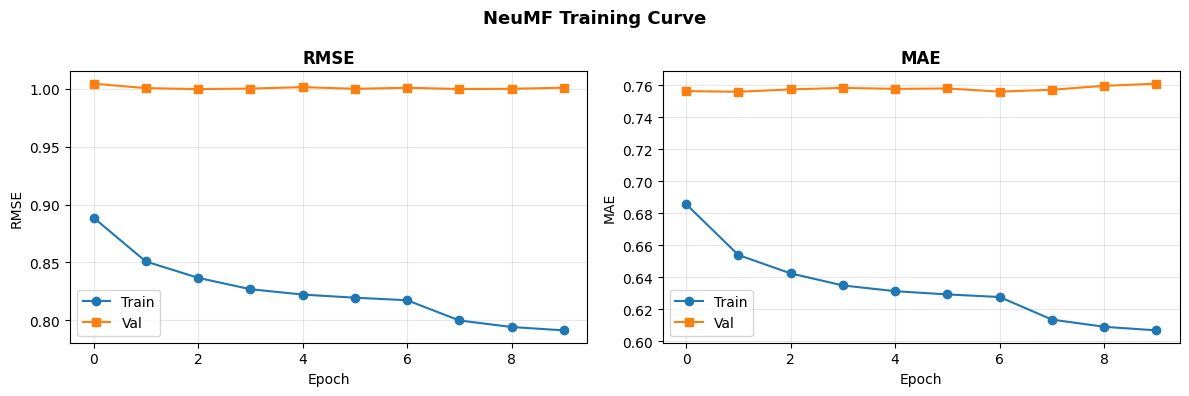

In [7]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['rmse', 'mae']):
    ax.plot(history[f'train_{metric}'], label='Train', marker='o')
    ax.plot(history[f'val_{metric}'],   label='Val',   marker='s')
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.upper())
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('NeuMF Training Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS / 'ncf_training_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Evaluate on Qualifying Users (Same Protocol as NB06 & NB07)

In [8]:
# Load CF baseline metrics and the same eval user set from NB06
with open(MODELS / 'cf_eval_metrics.pkl',  'rb') as f:
    cf_metrics = pickle.load(f)
with open(MODELS / 'mf_eval_metrics.pkl',  'rb') as f:
    mf_metrics = pickle.load(f)

# Build val lookup from validation parquet
val_full = pd.read_parquet(PROCESSED / 'ratings_val.parquet',
                           columns=['userId', 'movieId', 'rating'])
val_lookup_full = (
    val_full
    .groupby('userId')
    .apply(lambda g: dict(zip(g['movieId'], g['rating'])))
    .to_dict()
)

# Qualifying users: in user_enc (seen in training), ≥5 val ratings
MIN_VAL = 5
qual = [uid for uid in user_enc if uid in val_lookup_full
        and len(val_lookup_full[uid]) >= MIN_VAL]
np.random.seed(42)
np.random.shuffle(qual)
eval_users_ncf = qual[:200]
print(f"NCF eval pool: {len(eval_users_ncf)} qualifying users")

NCF eval pool: 200 qualifying users


In [9]:
model.eval()
ncf_preds = []

with torch.no_grad():
    for uid in eval_users_ncf:
        u_idx = user_enc[uid]
        for mid, true_r in val_lookup_full[uid].items():
            if mid in movie_enc:
                m_idx = movie_enc[mid]
                u_t   = torch.tensor([u_idx], dtype=torch.long, device=DEVICE)
                m_t   = torch.tensor([m_idx], dtype=torch.long, device=DEVICE)
                pred  = float(model(u_t, m_t).item())
            else:
                pred  = GLOBAL_MEAN
            ncf_preds.append((true_r, pred))

arr = np.array(ncf_preds)
ncf_rmse = float(np.sqrt(np.mean((arr[:,0] - arr[:,1])**2)))
ncf_mae  = float(np.mean(np.abs(arr[:,0] - arr[:,1])))
print(f"NeuMF  →  RMSE={ncf_rmse:.4f}  MAE={ncf_mae:.4f}  ({len(ncf_preds):,} predictions)")

NeuMF  →  RMSE=1.0725  MAE=0.8078  (14,956 predictions)


          Method     RMSE      MAE                 Type
  FunkSVD (30ep) 0.760014 0.562664 Matrix Factorisation
 SVD (user-mean) 0.958160 0.710898 Matrix Factorisation
            IBCF 0.964703 0.717450      Memory-Based CF
            UBCF 0.965266 0.722975      Memory-Based CF
     NeuMF (NCF) 1.072454 0.807808            Neural CF
NMF (calibrated) 1.093655 0.895832 Matrix Factorisation


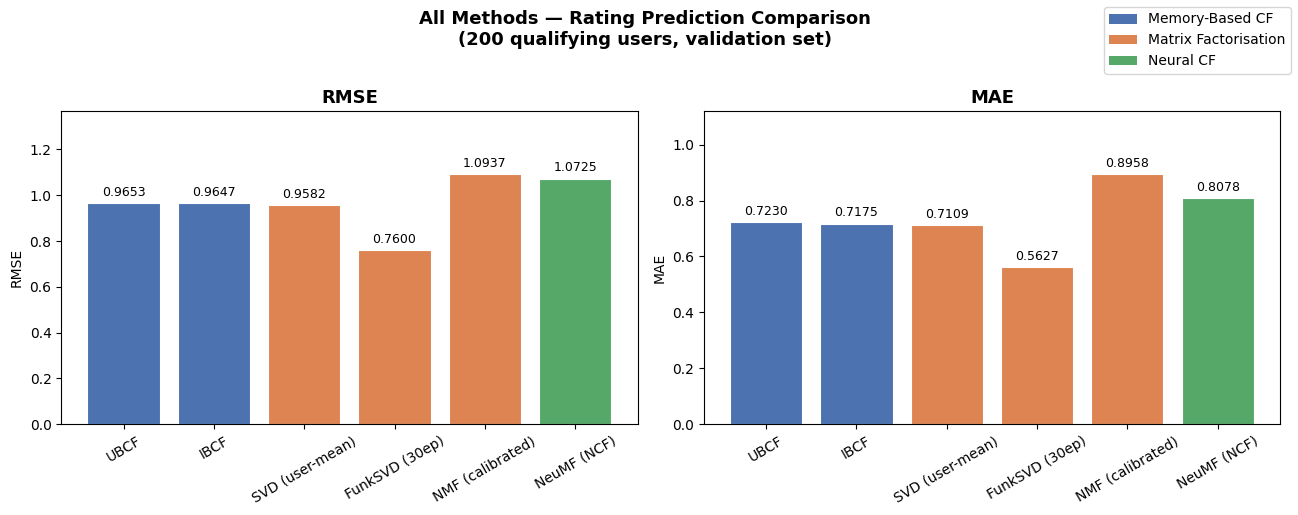

Chart saved.


In [10]:

# Full comparison chart: CF baselines + MF methods + NCF
# mf_metrics keys updated in NB07 fine-tuning: svd_global, svd_user, funk_20ep, funk_finetuned, nmf
all_results = pd.DataFrame([
    {'Method': 'UBCF',           'RMSE': cf_metrics['ubcf_rmse'], 'MAE': cf_metrics['ubcf_mae'],           'Type': 'Memory-Based CF'},
    {'Method': 'IBCF',           'RMSE': cf_metrics['ibcf_rmse'], 'MAE': cf_metrics['ibcf_mae'],           'Type': 'Memory-Based CF'},
    {'Method': 'SVD (user-mean)','RMSE': mf_metrics['svd_user']['rmse'], 'MAE': mf_metrics['svd_user']['mae'],  'Type': 'Matrix Factorisation'},
    {'Method': 'FunkSVD (30ep)', 'RMSE': mf_metrics['funk_finetuned']['rmse'], 'MAE': mf_metrics['funk_finetuned']['mae'], 'Type': 'Matrix Factorisation'},
    {'Method': 'NMF (calibrated)','RMSE': mf_metrics['nmf']['rmse'],  'MAE': mf_metrics['nmf']['mae'],     'Type': 'Matrix Factorisation'},
    {'Method': 'NeuMF (NCF)',    'RMSE': ncf_rmse,                   'MAE': ncf_mae,                        'Type': 'Neural CF'},
])

print(all_results.sort_values('RMSE').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'Memory-Based CF': '#4C72B0', 'Matrix Factorisation': '#DD8452', 'Neural CF': '#55A868'}
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    colors = [palette[t] for t in all_results['Type']]
    bars = ax.bar(all_results['Method'], all_results[metric], color=colors,
                  edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, all_results[metric].max() * 1.25)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel(metric)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=v, label=k) for k, v in palette.items()]
fig.legend(handles=legend_elems, loc='upper right', framealpha=0.8)
plt.suptitle('All Methods — Rating Prediction Comparison\n(200 qualifying users, validation set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(MODELS / 'all_methods_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Chart saved.")


## 6. Generate Top-N Recommendations with NeuMF

In [11]:
# Build a reverse movie index for title lookup
links = pd.read_csv(MOVIELENS / 'links.csv', usecols=['movieId','tmdbId'])
links = links.dropna(subset=['tmdbId'])
links['tmdbId']  = links['tmdbId'].astype(int)
links['movieId'] = links['movieId'].astype(int)
master_t = pd.read_parquet(PROCESSED / 'master_movies.parquet', columns=['tmdb_id','title'])
movie2title = links.merge(master_t, left_on='tmdbId', right_on='tmdb_id', how='left') \
                   .set_index('movieId')['title'].to_dict()

idx_to_movie_enc = {v: k for k, v in movie_enc.items()}

def ncf_recommend(user_id: int, n_recs: int = 10,
                  seen_movie_ids: set | None = None) -> pd.DataFrame:
    """
    Return top-N unseen movie recommendations for user using the trained NeuMF model.
    Falls back to global_mean score for movies not in the training index.
    """
    if user_id not in user_enc:
        raise ValueError(f"user_id {user_id} not seen during training.")
    u_idx = user_enc[user_id]
    all_movie_idxs = torch.arange(N_MOVIES, dtype=torch.long, device=DEVICE)
    u_tensor = torch.full((N_MOVIES,), u_idx, dtype=torch.long, device=DEVICE)

    model.eval()
    with torch.no_grad():
        scores = model(u_tensor, all_movie_idxs).cpu().numpy()

    # Mask already-seen movies
    if seen_movie_ids:
        for mid in seen_movie_ids:
            if mid in movie_enc:
                scores[movie_enc[mid]] = -1.0

    top_idxs = np.argsort(scores)[::-1][:n_recs]
    top_mids = [idx_to_movie_enc[i] for i in top_idxs]
    recs = pd.DataFrame({'movieId': top_mids, 'predicted_rating': scores[top_idxs]})
    recs['title'] = recs['movieId'].map(movie2title).fillna('Unknown')
    return recs[['title', 'predicted_rating']]

# Demo
demo_user = eval_users_ncf[0]
print(f"Top-10 NeuMF recommendations for user {demo_user}:\n")
print(ncf_recommend(demo_user).to_string(index=False))

Top-10 NeuMF recommendations for user 87789:

                                                               title  predicted_rating
                                                       Andrei Rublev          4.365291
                                                     Pather Panchali          4.322621
                                                Children of Paradise          4.315914
                                                       The Godfather          4.305727
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb          4.300831
                                                    The World of Apu          4.300283
                                                       The 400 Blows          4.271942
                                                       The Third Man          4.270351
                                                   Wild Strawberries          4.270113
                                                               Ikiru          4.2677

## 7. Save Model Artefacts

In [12]:
# Save model weights
torch.save(model.state_dict(), MODELS / 'ncf_model_weights.pt')

# Save encoder maps (needed for inference)
with open(MODELS / 'ncf_user_enc.pkl', 'wb') as f:
    pickle.dump(user_enc, f)
with open(MODELS / 'ncf_movie_enc.pkl', 'wb') as f:
    pickle.dump(movie_enc, f)

# Save NCF config for reconstruction at inference time
ncf_config = {
    'n_users': N_USERS, 'n_movies': N_MOVIES,
    'gmf_dim': 32, 'mlp_dim': 64, 'mlp_layers': [128, 64, 32],
    'dropout': 0.2
}
with open(MODELS / 'ncf_config.pkl', 'wb') as f:
    pickle.dump(ncf_config, f)

# Save evaluation metrics
ncf_metrics = {'ncf': {'rmse': ncf_rmse, 'mae': ncf_mae}}
with open(MODELS / 'ncf_eval_metrics.pkl', 'wb') as f:
    pickle.dump(ncf_metrics, f)

# Save user embeddings for hybrid model in NB09
with torch.no_grad():
    u_emb = (model.gmf_user_emb.weight.cpu().numpy() +
             model.mlp_user_emb.weight.cpu().numpy()[:, :32]) / 2
    i_emb = (model.gmf_item_emb.weight.cpu().numpy() +
             model.mlp_item_emb.weight.cpu().numpy()[:, :32]) / 2
np.save(MODELS / 'ncf_user_embeddings.npy', u_emb.astype(np.float32))
np.save(MODELS / 'ncf_item_embeddings.npy', i_emb.astype(np.float32))

print("Artefacts saved:")
for fname in ['ncf_model_weights.pt', 'ncf_user_enc.pkl', 'ncf_movie_enc.pkl',
              'ncf_config.pkl', 'ncf_eval_metrics.pkl', 'ncf_user_embeddings.npy', 'ncf_item_embeddings.npy']:
    p = MODELS / fname
    if p.exists():
        print(f"  {fname:<35}  {p.stat().st_size/1024:.1f} KB")

Artefacts saved:
  ncf_model_weights.pt                 102724.5 KB
  ncf_user_enc.pkl                     4656.3 KB
  ncf_movie_enc.pkl                    505.0 KB
  ncf_config.pkl                       0.1 KB
  ncf_eval_metrics.pkl                 0.1 KB
  ncf_user_embeddings.npy              30613.2 KB
  ncf_item_embeddings.npy              3591.8 KB
